In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("obesity_data.csv")
df.head()

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,Male,173.575262,71.982051,23.891783,4,Normal weight
1,69,Male,164.127306,89.959256,33.395209,2,Obese
2,46,Female,168.072202,72.930629,25.817737,4,Overweight
3,32,Male,168.459633,84.886912,29.912247,3,Overweight
4,60,Male,183.568568,69.038945,20.487903,3,Normal weight


In [4]:
df['Gender']=df.Gender.replace({"Male":0,"Female":1})
df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8196\1674502424.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender']=df.Gender.replace({"Male":0,"Female":1})


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,0,173.575262,71.982051,23.891783,4,Normal weight
1,69,0,164.127306,89.959256,33.395209,2,Obese
2,46,1,168.072202,72.930629,25.817737,4,Overweight
3,32,0,168.459633,84.886912,29.912247,3,Overweight
4,60,0,183.568568,69.038945,20.487903,3,Normal weight


In [5]:
df['ObesityCategory'].unique()

array(['Normal weight', 'Obese', 'Overweight', 'Underweight'],
      dtype=object)

In [6]:
df['ObesityCategory']=df.ObesityCategory.replace({'Normal weight':0,'Obese':1,'Overweight':2,'Underweight':3})
df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8196\437298291.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ObesityCategory']=df.ObesityCategory.replace({'Normal weight':0,'Obese':1,'Overweight':2,'Underweight':3})


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,0,173.575262,71.982051,23.891783,4,0
1,69,0,164.127306,89.959256,33.395209,2,1
2,46,1,168.072202,72.930629,25.817737,4,2
3,32,0,168.459633,84.886912,29.912247,3,2
4,60,0,183.568568,69.038945,20.487903,3,0


In [7]:
X=df.drop('ObesityCategory',axis=1)
y=df['ObesityCategory']

In [8]:
# choosing optimized model

In [9]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [10]:
model_params={
    'svm':{'model':svm.SVC(gamma='auto'),
           'params':{
               'C':[1,10,20],
               'kernel':['rbf','linear']
           }
          },
    'random_forest':{
        'model':RandomForestClassifier(),
        'params':{
            'n_estimators':[1,5,10,20]
        }
    },
    'logistic_regression':{
        'model':LogisticRegression(solver='liblinear',multi_class='auto'),
        'params':{
            'C':[1,5,10]
        }
    }
}

In [11]:
from sklearn.model_selection import GridSearchCV


In [12]:
scores=[]
for model_name,mp in model_params.items():
    clf=GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=False)
    clf.fit(X,y)
    scores.append({
        'model':model_name,
        'best_score':clf.best_score_,
        'best_params':clf.best_params_
    })
    
scores

C:\Users\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be remove

[{'model': 'svm',
  'best_score': np.float64(0.9879999999999999),
  'best_params': {'C': 10, 'kernel': 'linear'}},
 {'model': 'random_forest',
  'best_score': np.float64(0.994),
  'best_params': {'n_estimators': 10}},
 {'model': 'logistic_regression',
  'best_score': np.float64(0.914),
  'best_params': {'C': 1}}]

In [13]:
scores_df=pd.DataFrame(scores,columns=['model','best_score','best_params'])
scores_df

,model,best_score,best_params
0,svm,0.988,"{'C': 10, 'kernel': 'linear'}"
1,random_forest,0.994,{'n_estimators': 10}
2,logistic_regression,0.914,{'C': 1}


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'PhysicalActivityLevel'}>],
       [<Axes: title={'center': 'ObesityCategory'}>, <Axes: >, <Axes: >]],
      dtype=object)

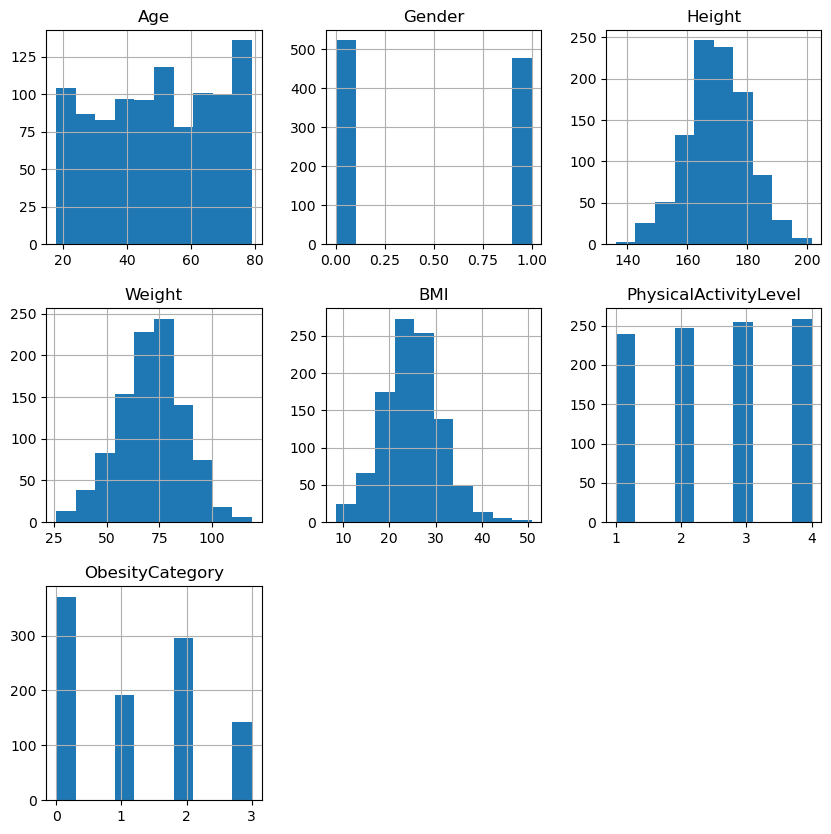

In [14]:
df.hist(figsize=(10,10))

In [15]:
df0=df[df.ObesityCategory==0]
df0

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,0,173.575262,71.982051,23.891783,4,0
4,60,0,183.568568,69.038945,20.487903,3,0
5,25,1,166.405627,61.145868,22.081628,4,0
8,56,0,183.478558,75.157672,22.325577,4,0
9,75,0,182.974061,81.533460,24.353244,2,0
...,...,...,...,...,...,...,...
990,22,1,181.590152,72.609417,22.019546,4,0
991,72,0,171.211180,54.413897,18.562890,1,0
993,50,0,177.754455,64.719166,20.482923,4,0
998,64,0,164.192222,57.978115,21.505965,4,0


In [16]:
df1=df[df.ObesityCategory==1]
df1

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
1,69,0,164.127306,89.959256,33.395209,2,1
14,41,0,144.706626,82.160555,39.236163,1,1
22,19,0,143.527471,83.796214,40.677507,2,1
27,19,0,169.801184,92.587274,32.112186,3,1
29,38,0,168.280866,89.904528,31.747687,1,1
...,...,...,...,...,...,...,...
983,19,1,154.667254,72.838480,30.448375,4,1
985,73,0,164.933895,84.746764,31.153245,2,1
994,71,1,146.156433,101.587522,47.555910,2,1
996,35,1,165.076490,97.639771,35.830783,1,1


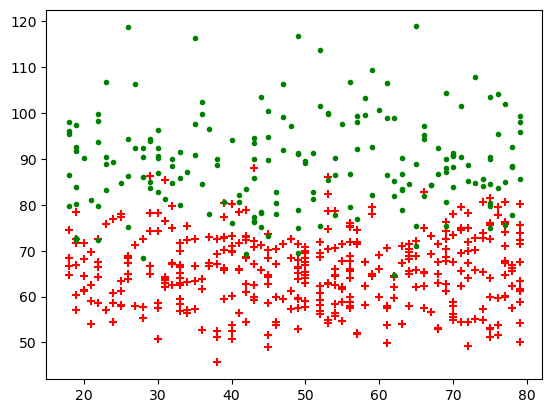

In [17]:
plt.scatter(df0['Age'],df0['Weight'],color='red',marker='+')
plt.scatter(df1['Age'],df1['Weight'],color='green',marker='.')

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

rf_model=RandomForestClassifier(n_estimators=10,max_depth=None,random_state=42)

In [19]:
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)

from sklearn.metrics import r2_score
accuracy=r2_score(y_test,y_pred)
accuracy

0.983731570920183

In [20]:
x_input=(21,1,158,60,66,0)
x_input_arr=np.asarray(x_input)
x_reshape=x_input_arr.reshape(1,-1)

prediction=rf_model.predict(x_reshape)

C:\Users\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [21]:
if(prediction[0]==0):
    print("Normal Weight")
elif(prediction[0]==1):
    print("Obese")
elif(prediction[0]==2):
    print("Over Weight")
else:
    print("Under Weight")

Obese


In [22]:
import pickle

filename='obesity_prediction.sav'
pickle.dump(rf_model,open(filename,'wb'))

In [23]:
for column in X.columns:
    print(column)

Age
Gender
Height
Weight
BMI
PhysicalActivityLevel
